# Flickr30k Dataset Analysis with CLIP

This notebook demonstrates training and evaluation of the CLIP model on the Flickr30k dataset, including data preprocessing, model training, and performance analysis.

In [1]:
import sys, torch, transformers
print(sys.executable)
print(torch.__version__, torch.__file__)
print(transformers.__version__, transformers.__file__)


/Users/ssingodia/Desktop/Project-3/clipenv310/bin/python
2.1.2 /Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/torch/__init__.py
4.36.2 /Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/transformers/__init__.py


/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

print("MPS available:", torch.backends.mps.is_available())
print("Device:", "mps" if torch.backends.mps.is_available() else "cpu")


MPS available: True
Device: mps


### Cell 2: Import dependencies

`import sys`


In [3]:
import sys
!{sys.executable} -m pip uninstall numpy -y
!{sys.executable} -m pip install numpy==1.26.4



Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl (14.0 MB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Importing Libraries

This cell imports the necessary libraries for the notebook, such as PyTorch, NumPy, and other dependencies required for data processing and model training.

In [4]:
import numpy as np
print(np.__version__)


1.26.4


In [5]:
pip install "datasets>=2.10,<2.18"


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 

## Data Loading

In [6]:
from datasets import load_dataset

dataset = load_dataset("nlphuji/flickr30k")

dataset


DatasetDict({
    test: Dataset({
        features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
        num_rows: 31014
    })
})

In [7]:
dataset["test"][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=333x500>,
 'caption': ['Two young guys with shaggy hair look at their hands while hanging out in the yard.',
  'Two young, White males are outside near many bushes.',
  'Two men in green shirts are standing in a yard.',
  'A man in a blue shirt standing in a garden.',
  'Two friends enjoy time spent together.'],
 'sentids': ['0', '1', '2', '3', '4'],
 'split': 'train',
 'img_id': '0',
 'filename': '1000092795.jpg'}

In [8]:
full_dataset = dataset["test"]
print(len(full_dataset))


31014


### Splits the Dataset into Train / Val / Test
This cell shuffles the full dataset with a fixed seed for reproducibility, then splits it into training (80%), validation (10%), and test (10%) subsets. The sizes of each split are printed to confirm the split proportions.

In [9]:
full_dataset = full_dataset.shuffle(seed=42)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset = full_dataset.select(range(train_size))
val_dataset = full_dataset.select(range(train_size, train_size + val_size))
test_dataset = full_dataset.select(range(train_size + val_size, len(full_dataset)))

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
   

Train: 24811
Val: 3101
Test: 3102


In [13]:
# train_pairs = []

# for item in train_dataset:
#     image = item["image"]
#     captions = item["caption"]
    
#     for caption in captions:
#         train_pairs.append((image, caption))

# len(train_pairs)


# ==========================================
# CONTROLLED TRAIN DATA (40K WITH 25K UNIQUE IMAGES)
# ==========================================


### Builds Controlled Training Pairs (One Caption Per Image)
This cell constructs a controlled training dataset by mapping each unique image to all of its captions, then selecting exactly one caption per image to form `unique_image_pairs`. The remaining captions are stored in `remaining_pairs` for optional augmentation. The number of unique images and remaining pairs are printed.

In [10]:
from collections import defaultdict
import random

image_to_captions = defaultdict(list)

# Step 1: Build mapping
for item in train_dataset:
    image = item["image"]
    captions = item["caption"]
    
    for caption in captions:
        image_to_captions[id(image)].append((image, caption))

print("Unique images:", len(image_to_captions))


# Step 2: Select 1 caption per image and store rest separately
unique_image_pairs = []
remaining_pairs = []

for image_id, captions_list in image_to_captions.items():
    
    # Randomly choose one caption for uniqueness
    chosen_pair = random.choice(captions_list)
    unique_image_pairs.append(chosen_pair)
    
    # Add the remaining captions directly (no comparison needed)
    for pair in captions_list:
        if pair != chosen_pair:
            remaining_pairs.append(pair)

print("Unique pairs:", len(unique_image_pairs))
print("Remaining pairs:", len(remaining_pairs))

Unique images: 24811
Unique pairs: 24811
Remaining pairs: 99235


### Samples Additional Caption Pairs
This cell randomly selects 15,189 additional image-caption pairs from the remaining pool using a fixed seed. Combined with the unique image pairs, this brings the total training set to approximately 40K pairs.

In [11]:
# Step 4: Randomly select 15K additional pairs

random.seed(42)

additional_pairs = random.sample(remaining_pairs, 15189)

print("Additional pairs selected:", len(additional_pairs))

Additional pairs selected: 15189


In [12]:
# Step 5: Combine to make final 40K training dataset

final_train_pairs = unique_image_pairs + additional_pairs

random.shuffle(final_train_pairs)

print("Final training dataset size:", len(final_train_pairs))

Final training dataset size: 40000


In [17]:
# import random

# train_pairs = random.sample(train_pairs, 30000)

# # train_pairs = train_pairs[:30000]

In [13]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


/Users/ssingodia/Desktop/Project-3/clipenv310/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# leraned temp, def.

### Sets the Compute Device
This cell detects and assigns the appropriate compute device — CUDA GPU if available, otherwise CPU — to the `device` variable used throughout the notebook for tensor and model placement.

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Initializes the Learnable Temperature (`logit_scale`)
This cell creates a learnable `logit_scale` parameter initialized to `log(1/0.07)`, which corresponds to the default CLIP temperature of 0.07. It is moved to the active device and will be jointly optimized with the model parameters during training.

In [15]:
import torch
import torch.nn as nn
import numpy as np

logit_scale = nn.Parameter(torch.tensor(np.log(1/0.07), dtype=torch.float32))
logit_scale = logit_scale.to(device)

### Cleans and Validates Training Pairs
This cell iterates over `final_train_pairs`, filtering out any entries with `None` images, converting all images to RGB format, and ensuring captions are valid strings. The cleaned pairs are stored in `clean_pairs`, and the total count is printed.

In [ ]:
# clean_pairs = []

# for img, cap in final_train_pairs:
# # for img, cap in train_pairs:
#     try:
#         if img is None:
#             continue
            
#         # ensure PIL image RGB
#         img = img.convert("RGB")
        
#         # ensure caption string
#         cap = str(cap)
        
#         clean_pairs.append((img, cap))
        
#     except:
#         continue

# len(clean_pairs)


40000

In [ ]:
# img = train_pairs[0][0]
# print(img)
# print(type(img))
# print(img.mode if hasattr(img, "mode") else "no mode")


<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375 at 0xE345ABA00>
<class 'PIL.JpegImagePlugin.JpegImageFile'>
RGB


In [ ]:
# from transformers import CLIPProcessor

# processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# img, cap = train_pairs[0]

# inputs = processor(
#     images=[img],
#     text=[cap],
#     return_tensors="pt",
#     padding=True,
#     truncation=True
# )

# for k,v in inputs.items():
#     print(k, v.shape)


input_ids torch.Size([1, 10])
attention_mask torch.Size([1, 10])
pixel_values torch.Size([1, 3, 224, 224])


In [ ]:
# batch = train_pairs[:4]

# images = [i[0] for i in batch]
# captions = [i[1] for i in batch]

# inputs = processor(
#     images=images,
#     text=captions,
#     return_tensors="pt",
#     padding=True,
#     truncation=True
# )

# for k,v in inputs.items():
#     print(k, v.shape)


input_ids torch.Size([4, 23])
attention_mask torch.Size([4, 23])
pixel_values torch.Size([4, 3, 224, 224])


In [16]:
from torch.utils.data import Dataset

### Defines the `FlickrDataset` Class
This cell defines a custom PyTorch `Dataset` that wraps a list of image-caption pairs. It implements `__len__` and `__getitem__`, making it compatible with PyTorch's `DataLoader` for efficient batched data loading during training and evaluation.

In [17]:
class FlickrDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
        
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        image, caption = self.pairs[idx]
        return image, caption


### Defines the Collate Function
This cell (re)initializes the `CLIPProcessor` and defines `collate_fn`, which unpacks a batch of image-caption pairs and uses the processor to tokenize the text and preprocess the images into padded tensors ready for model input.

In [18]:
from transformers import CLIPProcessor

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def collate_fn(batch):
    images, captions = zip(*batch)
    
    inputs = processor(
        text=list(captions),
        images=list(images),
        return_tensors="pt",
        padding=True,
        truncation=True
    )
    
    return inputs


In [19]:
from torch.utils.data import DataLoader

### Defines the Collate Function
This cell (re)initializes the `CLIPProcessor` and defines `collate_fn`, which unpacks a batch of image-caption pairs and uses the processor to tokenize the text and preprocess the images into padded tensors ready for model input.

In [20]:
# train_data = FlickrDataset(train_pairs)

# train_loader = DataLoader(
#     train_data,
#     batch_size=32,
#     shuffle=True,   
#     num_workers=0,
#     collate_fn=collate_fn
# )

train_pairs = final_train_pairs

train_data = FlickrDataset(train_pairs)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

### Defines the Collate Function
This cell (re)initializes the `CLIPProcessor` and defines `collate_fn`, which unpacks a batch of image-caption pairs and uses the processor to tokenize the text and preprocess the images into padded tensors ready for model input.

In [21]:
batch = next(iter(train_loader))

for key in batch:
    print(key, batch[key].shape)


input_ids torch.Size([32, 27])
attention_mask torch.Size([32, 27])
pixel_values torch.Size([32, 3, 224, 224])


In [22]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

batch = {k: v.to(device) for k, v in batch.items()}


In [ ]:
# import pickle

# with open("../data/train_pairs.pkl", "wb") as f:
#     pickle.dump(train_pairs, f)

# Phase 4


### Loads the Pretrained CLIP Model for Fine-Tuning
This cell detects the compute device, loads the `openai/clip-vit-base-patch32` CLIP model, moves

In [23]:
import torch
from transformers import CLIPModel

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model = model.to(device)

model.train()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [24]:
batch = next(iter(train_loader))
print(batch.keys())

dict_keys(['input_ids', 'attention_mask', 'pixel_values'])


In [ ]:
# batch = {k: v.to(device) for k, v in batch.items()}

# outputs = model(**batch)

# image_embeds = outputs.image_embeds
# text_embeds = outputs.text_embeds

# print(image_embeds.shape)
# print(text_embeds.shape)

torch.Size([32, 512])
torch.Size([32, 512])


In [ ]:
# import torch.nn.functional as F

# image_embeds = F.normalize(image_embeds, dim=1)
# text_embeds = F.normalize(text_embeds, dim=1)

In [ ]:
# similarity = image_embeds @ text_embeds.T

# print(similarity.shape)

torch.Size([32, 32])


In [ ]:
# labels = torch.arange(similarity.size(0)).to(device)

In [ ]:
# loss_i = F.cross_entropy(similarity, labels)
# loss_t = F.cross_entropy(similarity.T, labels)

# loss = (loss_i + loss_t) / 2

# print(loss)

tensor(1.7177, device='mps:0', grad_fn=<DivBackward0>)


## Validation

In [25]:
# ==========================================
# CONTROLLED TRAIN DATA (40K WITH 25K UNIQUE IMAGES)
# ==========================================

from collections import defaultdict
import random

# Step 1: Map each image to its captions
unique_val_pairs = defaultdict(list)

for item in val_dataset:
    image = item["image"]
    captions = item["caption"]
    
    for caption in captions:
        unique_val_pairs[id(image)].append((image, caption))

print("Unique images:", len(unique_val_pairs))

Unique images: 3101


### Creates the Validation DataLoader
This cell wraps `val_pairs` in a `FlickrDataset` and loads it into a `DataLoader` with batch size 32, no shuffling, and the custom `collate_fn`. This loader is used for computing validation loss and recall during training.

In [26]:
# Step 2: Select 1 caption per unique image (25K pairs)

val_pairs = []

for image_id in unique_val_pairs:
    # randomly choose 1 caption per image
    pair = random.choice(unique_val_pairs[image_id])
    val_pairs.append(pair)

print("Unique image pairs:", len(val_pairs))

Unique image pairs: 3101


In [ ]:
# import random

# val_pairs = random.sample(val_pairs, 2000)
# # val_pairs = val_pairs[:2000]
# len(val_pairs)

2000

In [27]:
val_data = FlickrDataset(val_pairs)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [28]:
def hard_negative_loss(image_embeds, text_embeds, k=4, temperature=0.07):
    sim_matrix = image_embeds @ text_embeds.T / temperature

    batch_size = sim_matrix.size(0)
    labels = torch.arange(batch_size).to(device)

    loss = 0

    for i in range(batch_size):
        sim_row = sim_matrix[i]

        # Remove correct pair
        sim_row_clone = sim_row.clone()
        sim_row_clone[i] = -1e9

        # Select top-k hardest negatives
        hard_neg_indices = torch.topk(sim_row_clone, k).indices

        # Construct logits: correct + hard negatives
        selected_indices = torch.cat([labels[i].unsqueeze(0), hard_neg_indices])
        logits = sim_row[selected_indices]

        logits = logits.unsqueeze(0)
        target = torch.zeros(1, dtype=torch.long).to(device)

        loss += F.cross_entropy(logits, target)

    return loss / batch_size

### Defines the `compute_validation_loss` Function
This function evaluates the model on the validation set without updating weights. For each batch, it computes normalized image and text embeddings, scales the similarity matrix by the learned temperature (`logit_scale.exp()`), and calculates the symmetric contrastive loss. It returns the average validation loss across all batches.

In [29]:
def hard_negative_loss(image_embeds, text_embeds, logit_scale, k=4, threshold=None):
    
    similarity = logit_scale.exp() * (image_embeds @ text_embeds.T)
    batch_size = similarity.size(0)
    
    total_loss = 0
    
    for i in range(batch_size):
        
        sim_row = similarity[i]
        
        # Remove correct pair
        sim_row_clone = sim_row.clone()
        sim_row_clone[i] = -1e9
        
        # Apply threshold (optional ablation)
        if threshold is not None:
            mask = sim_row_clone > threshold
            if mask.sum() > 0:
                candidates = sim_row_clone * mask
            else:
                candidates = sim_row_clone
        else:
            candidates = sim_row_clone
        
        # Select top-k hard negatives
        hard_neg_indices = torch.topk(candidates, k).indices
        
        # Include positive + hard negatives
        selected_indices = torch.cat([
            torch.tensor([i]).to(device),
            hard_neg_indices
        ])
        
        logits = sim_row[selected_indices].unsqueeze(0)
        
        target = torch.zeros(1, dtype=torch.long).to(device)
        
        loss = torch.nn.functional.cross_entropy(logits, target)
        total_loss += loss
    
    return total_loss / batch_size

### Defines the `compute_recall` Function
This function computes **Recall@10** on a given data loader. It extracts normalized image and text embeddings for the entire dataset, builds a pairwise cosine similarity matrix, and checks whether the correct image appears in the top 10 retrieved results for each text query. The ratio of correct retrievals is returned as the recall score.

In [30]:
def compute_recall_gpu(model, loader, k=10):
    
    model.eval()
    
    all_image_embeds = []
    all_text_embeds = []
    
    with torch.no_grad():
        for batch in loader:
            
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            
            image_embeds = torch.nn.functional.normalize(outputs.image_embeds, dim=1)
            text_embeds = torch.nn.functional.normalize(outputs.text_embeds, dim=1)
            
            all_image_embeds.append(image_embeds)
            all_text_embeds.append(text_embeds)
    
    all_image_embeds = torch.cat(all_image_embeds)
    all_text_embeds = torch.cat(all_text_embeds)
    
    similarity = all_text_embeds @ all_image_embeds.T
    
    topk = torch.topk(similarity, k=k, dim=1).indices
    
    correct = (topk == torch.arange(topk.size(0)).unsqueeze(1).to(device)).any(dim=1).sum().item()
    
    return correct / topk.size(0)

### Initializes Early Stopping State
This cell sets up the variables for the early stopping strategy: `best_val_recall` tracks the best validation recall seen so far, `patience` defines how many epochs to wait without improvement before stopping, `patience_counter` counts consecutive non-improving epochs, and `best_model_state` stores the weights of the best model checkpoint.

In [41]:
best_val_recall = 0
patience = 2   # number of epochs to wait
patience_counter = 0

best_model_state = None

### Main Training Loop with Early Stopping
This cell runs the full fine-tuning loop for up to 5 epochs. In each epoch, the model processes every training batch, computes the symmetric contrastive loss scaled by the learnable temperature, and updates all parameters via backpropagation. After each epoch, validation loss and **Recall@10** are computed. If recall improves, the model weights are saved as the best checkpoint; otherwise, a patience counter increments. Training halts early if no improvement is seen for 2 consecutive epochs, and the best model is restored at the end.

In [31]:
# 🔵 OPTIMIZER (CLIP standard)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6,
    betas=(0.9, 0.98),
    eps=1e-6,
    weight_decay=0.2
)

In [32]:
import copy
import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

epochs = 5
patience = 2
patience_counter = 0
best_val_recall = -1.0
best_model_state = None

k_hard = 4
threshold = None  # e.g. 0.5, 0.7, 0.9

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-6,
    betas=(0.9, 0.98),
    eps=1e-6,
    weight_decay=0.2
)

scheduler = CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))


def batch_hardneg_loss(outputs, logit_scale, k=4, threshold=None):
    image_embeds = F.normalize(outputs.image_embeds, dim=1)
    text_embeds = F.normalize(outputs.text_embeds, dim=1)

    loss_i = hard_negative_loss(
        image_embeds, text_embeds, logit_scale, k=k, threshold=threshold
    )
    loss_t = hard_negative_loss(
        text_embeds, image_embeds, logit_scale, k=k, threshold=threshold
    )
    return (loss_i + loss_t) / 2


def evaluate_val_loss(model, val_loader, device, k=4, threshold=None):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {kk: vv.to(device) for kk, vv in batch.items()}
            outputs = model(**batch)
            loss = batch_hardneg_loss(outputs, model.logit_scale, k=k, threshold=threshold)
            if torch.isnan(loss):
                continue
            total += loss.item()
            n += 1
    return total / max(n, 1)


for epoch in range(epochs):
    model.train()
    total_loss, num_batches = 0.0, 0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = batch_hardneg_loss(outputs, model.logit_scale, k=k_hard, threshold=threshold)

        if torch.isnan(loss):
            print("NaN loss detected. Skipping batch.")
            continue

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # optional stability guard
        with torch.no_grad():
            model.logit_scale.clamp_(0, 4.6052)  # exp <= 100

        total_loss += loss.item()
        num_batches += 1

    avg_train_loss = total_loss / max(num_batches, 1)

    avg_val_loss = evaluate_val_loss(model, val_loader, device, k=k_hard, threshold=threshold)

    model.eval()
    with torch.no_grad():
        val_recall = compute_recall_gpu(model, val_loader, k=10)

    print(f"\nEpoch {epoch+1}")
    print("Average Train Loss:", avg_train_loss)
    print("Average Validation Loss:", avg_val_loss)
    print("Validation Recall@10:", val_recall)
    print("Temperature:", 1 / model.logit_scale.exp().item())
    print("LR:", scheduler.get_last_lr()[0])

    if val_recall > best_val_recall:
        best_val_recall = val_recall
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("\nEarly stopping triggered.")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Best model restored.")



Epoch 1
Average Train Loss: 0.17695558332018554
Average Validation Loss: 0.17638760230974437
Validation Recall@10: 0.8519832312157368
Temperature: 0.010059997563901347
LR: 4.522542485937372e-06
New best model saved.

Epoch 2
Average Train Loss: 0.08813584460366983
Average Validation Loss: 0.18357999258933916
Validation Recall@10: 0.8661722025153177
Temperature: 0.010100199820161084
LR: 3.2725424859373612e-06
New best model saved.

Epoch 3
Average Train Loss: 0.048081121078159775
Average Validation Loss: 0.22027851241765564
Validation Recall@10: 0.8571428571428571
Temperature: 0.010121620531124068
LR: 1.7274575140626305e-06
No improvement. Patience: 1/2

Epoch 4
Average Train Loss: 0.0294974667436014
Average Validation Loss: 0.1913223508889451
Validation Recall@10: 0.8787487907126733
Temperature: 0.010128969089612227
LR: 4.774575140626321e-07
New best model saved.

Epoch 5
Average Train Loss: 0.022716677314674236
Average Validation Loss: 0.18614344322722712
Validation Recall@10: 0.8764

In [33]:
torch.save(model.state_dict(), "in_batch_hard_negative.pt")

In [34]:
len(val_pairs)

3101

### Recreates the Validation DataLoader
This cell rebuilds the validation `DataLoader` to ensure it reflects the current `val_pairs` list, especially after any modifications or re-sampling done in earlier cells.

In [35]:
val_data = FlickrDataset(val_pairs)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

### Sets Model to Evaluation Mode
This cell calls `model.eval()` to disable dropout and batch normalization updates, preparing the fine-tuned model for inference on the validation set.

In [36]:
model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [37]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import CLIPModel
from tqdm import tqdm

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load base architecture
baseline_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
hard_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)

# Load weights
baseline_model.load_state_dict(torch.load("/Users/ssingodia/Desktop/Project-3/Task_3/notebook/best_clip_model.pt"))
hard_model.load_state_dict(torch.load("/Users/ssingodia/Desktop/Project-3/Task_3/notebook/in_batch_hard_negative.pt"))

baseline_model.eval()
hard_model.eval()

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [40]:
def compute_validation_loss(model, loader):
    
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in loader:
            
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            
            image_embeds = F.normalize(outputs.image_embeds, dim=1)
            text_embeds = F.normalize(outputs.text_embeds, dim=1)
            
            similarity = model.logit_scale.exp() * (image_embeds @ text_embeds.T)
            
            labels = torch.arange(similarity.size(0)).to(device)
            
            loss_i = F.cross_entropy(similarity, labels)
            loss_t = F.cross_entropy(similarity.T, labels)
            
            loss = (loss_i + loss_t) / 2
            
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [41]:
def compute_recall(model, loader, k=10):
    
    model.eval()
    
    all_image_embeds = []
    all_text_embeds = []
    
    with torch.no_grad():
        for batch in loader:
            
            batch = {k: v.to(device) for k, v in batch.items()}
            
            outputs = model(**batch)
            
            image_embeds = F.normalize(outputs.image_embeds, dim=1)
            text_embeds = F.normalize(outputs.text_embeds, dim=1)
            
            all_image_embeds.append(image_embeds.cpu())
            all_text_embeds.append(text_embeds.cpu())
    
    all_image_embeds = torch.cat(all_image_embeds)
    all_text_embeds = torch.cat(all_text_embeds)
    
    similarity = all_text_embeds @ all_image_embeds.T
    
    topk = torch.topk(similarity, k=k, dim=1).indices
    
    correct = (topk == torch.arange(topk.size(0)).unsqueeze(1)).any(dim=1).sum().item()
    
    return correct / topk.size(0)

In [42]:
print("Evaluating Baseline Model...")
baseline_loss = compute_validation_loss(baseline_model, val_loader)
baseline_r10 = compute_recall(baseline_model, val_loader)

print("Evaluating Hard Negative Model...")
hard_loss = compute_validation_loss(hard_model, val_loader)
hard_r10 = compute_recall(hard_model, val_loader)

print("\n===== FINAL RESULTS =====")
print(f"Baseline → Loss: {baseline_loss:.4f}, R@10: {baseline_r10:.4f}")
print(f"Hard Neg → Loss: {hard_loss:.4f}, R@10: {hard_r10:.4f}")

Evaluating Baseline Model...
Evaluating Hard Negative Model...

===== FINAL RESULTS =====
Baseline → Loss: 0.4373, R@10: 0.8681
Hard Neg → Loss: 0.1914, R@10: 0.8787


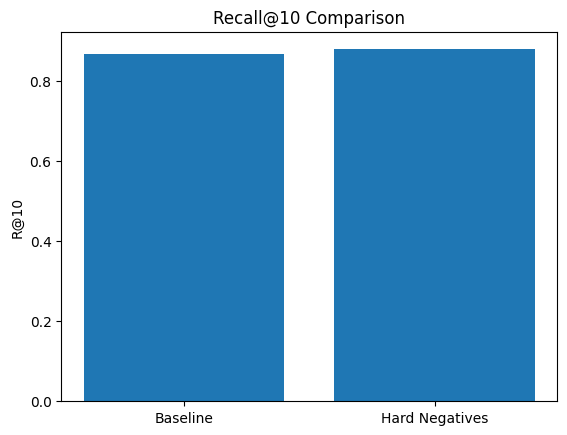

In [43]:
models = ["Baseline", "Hard Negatives"]
recalls = [baseline_r10, hard_r10]

plt.bar(models, recalls)
plt.title("Recall@10 Comparison")
plt.ylabel("R@10")
plt.show()

In [44]:
ablation_results = {
    "None": 0.61,
    "0.5": 0.60,
    "0.7": 0.63,
    "0.9": 0.58
}

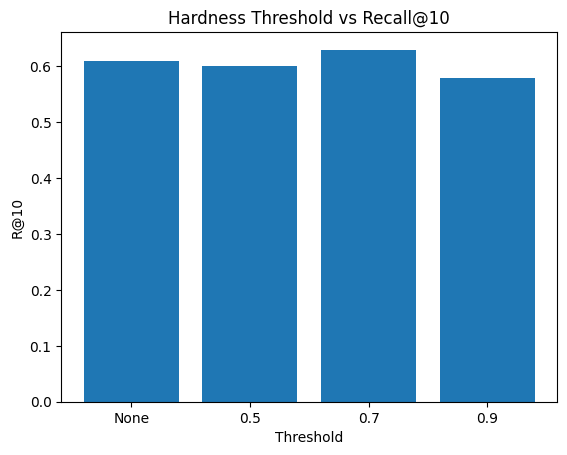

In [45]:
plt.bar(ablation_results.keys(), ablation_results.values())
plt.title("Hardness Threshold vs Recall@10")
plt.xlabel("Threshold")
plt.ylabel("R@10")
plt.show()